In [147]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


**DATA ANALYSIS of TRAIN and TEST SETS**

In [148]:
train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")
IDtest = test["PassengerId"]

In [149]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [150]:
# We will find outlier training examples which have very outlying values in more than 2 out of "Age","SibSp","Parch","Fare"
# Using Turkey method for deciding outlier thresholds

from collections import Counter
def detect_outliers(n,columns,data):
    outlier_indices = []
    for column in columns:
        Q1 = np.percentile(data[column],25)
        Q3 = np.percentile(data[column],75)
        IQR = Q3-Q1

        lower_bound = Q1 - 1.5*IQR
        upper_bound = Q3 + 1.5*IQR

        outliers_for_column = data[(data[column]<lower_bound) | (data[column]>upper_bound)].index
        outlier_indices.extend(outliers_for_column)
    outlier_counts = Counter(outlier_indices)
    multiple_outliers = list(k for (k,v) in outlier_counts.items() if v>n)
    
    return multiple_outliers
outliers_to_drop = detect_outliers(2,["Age","SibSp","Parch","Fare"],train)

In [151]:
# View outlier training examples
train.iloc[outliers_to_drop]
# We will drop these outliers to prevent model from learning incorrect patterns

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.00,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.00,C23 C25 C27,S
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.00,C23 C25 C27,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [152]:
train = train.drop(outliers_to_drop,axis=0).reset_index(drop=True)

In [153]:
# Join training and testing data to avoid doing same modifications repeatedly to both
dataset = pd.concat([train,test],axis=0).reset_index(drop=True)

In [154]:
print(len(test))

418


In [155]:
dataset = dataset.fillna(np.nan)
dataset.isnull().sum()

# Survived null are from testing data - no need to worry about that
# Age and Cabin are most common missing features

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             256
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1007
Embarked          2
dtype: int64

In [156]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  881 non-null    int64  
 1   Survived     881 non-null    int64  
 2   Pclass       881 non-null    int64  
 3   Name         881 non-null    object 
 4   Sex          881 non-null    object 
 5   Age          711 non-null    float64
 6   SibSp        881 non-null    int64  
 7   Parch        881 non-null    int64  
 8   Ticket       881 non-null    object 
 9   Fare         881 non-null    float64
 10  Cabin        201 non-null    object 
 11  Embarked     879 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 82.7+ KB


In [157]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            170
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          680
Embarked         2
dtype: int64

In [158]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,881.000000,881.000000,881.000000,711.000000,881.000000,881.000000,881.000000
mean,446.713961,0.385925,2.307605,29.731603,0.455165,0.363224,31.121566
std,256.617021,0.487090,0.835055,14.547835,0.871571,0.791839,47.996249
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,226.000000,0.000000,2.000000,20.250000,0.000000,0.000000,7.895800
50%,448.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.000000,1.000000,3.000000,38.000000,1.000000,0.000000,30.500000
max,891.000000,1.000000,3.000000,80.000000,5.000000,6.000000,512.329200


In [159]:
train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

**FEATURE-WISE ANALYSIS**

Correlation Matrix

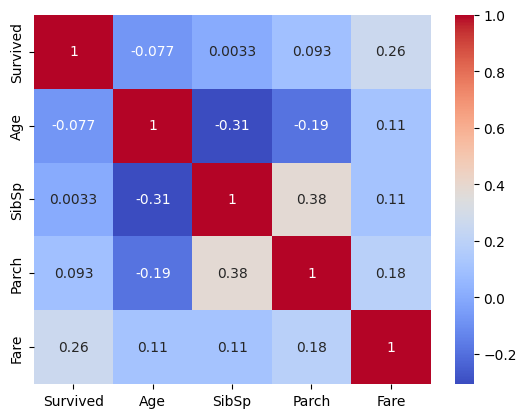

In [160]:
import seaborn as sns
g = sns.heatmap(train[["Survived","Age","SibSp","Parch","Fare"]].corr(),cmap="coolwarm",annot=True)

# Only Fare has significant positive correlation with Survival

SibSp Analysis

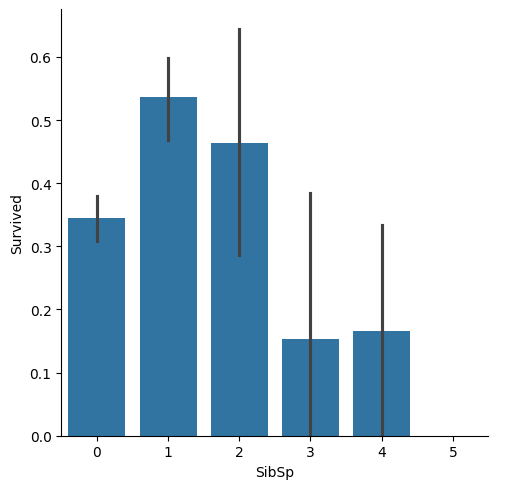

In [161]:
# But negative or small positive correlated features might also have subsets which are highly correlated but the overall
# feature does not seem well correlated

g = sns.catplot(data=train,x="SibSp",y="Survived",kind="bar")

# >=3,4 SibSp have low chances of survival

Parch Analysis

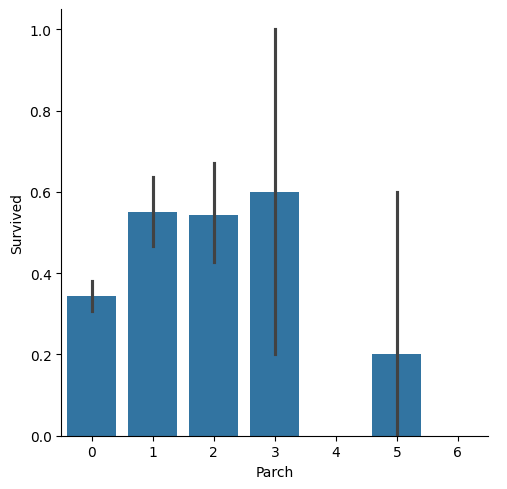

In [162]:
g = sns.catplot(data=train,x="Parch",y="Survived",kind="bar")
# Smaller families have higher chances of survival alhough, alone passengers have low survival chance

Age Analysis

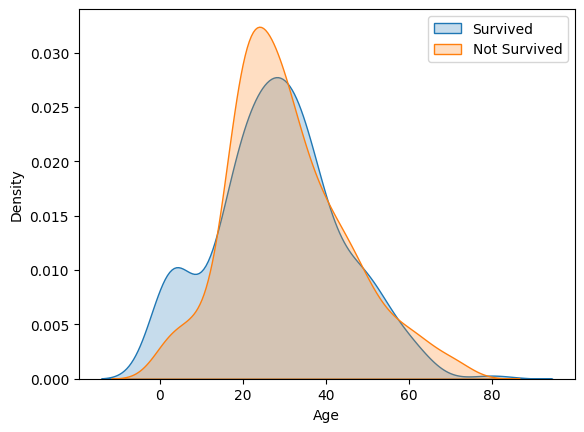

In [163]:
g = sns.kdeplot(train[train["Survived"]==1]["Age"],fill=True)
g = sns.kdeplot(train[train["Survived"]==0]["Age"],fill=True)
g = g.legend(["Survived","Not Survived"])

# Very small age passengers have higher chances of survival

Fare Analysis

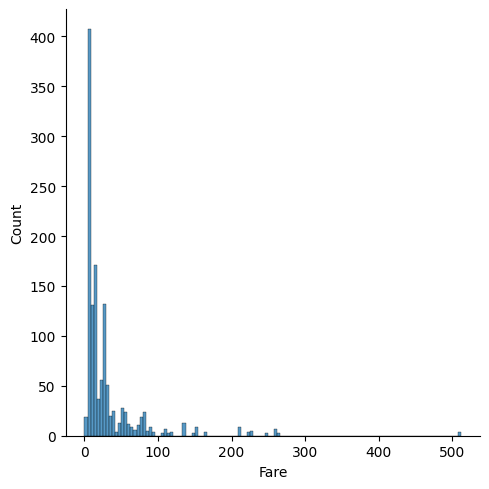

In [164]:
# Distribution of Fare
g = sns.displot(dataset["Fare"])
# Clearly the data is very skewed and most of the data is on left side - This can be solved by shifting to log scale

In [165]:
dataset["Fare"]=dataset["Fare"].map(lambda f: np.log(f) if f>0 else 0)

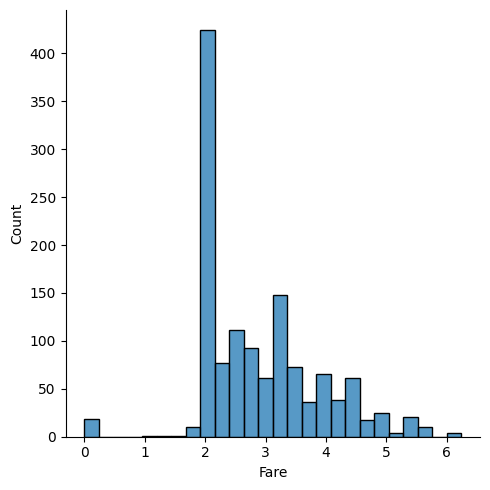

In [166]:
g = sns.displot(dataset["Fare"])
# It is now better evenly distributed

Sex

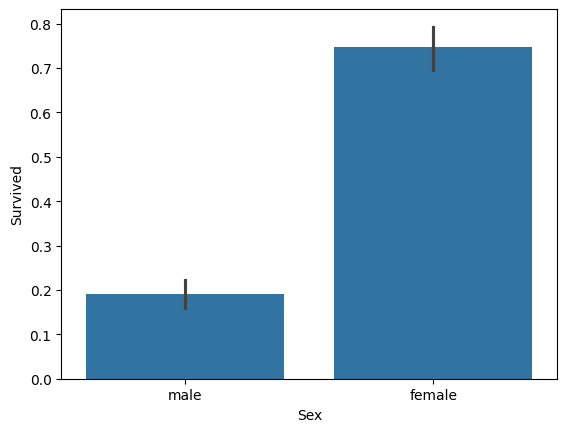

In [167]:
g = sns.barplot(x="Sex",y="Survived",data=train)
# Male have much lower chances of survival than females

Pclass

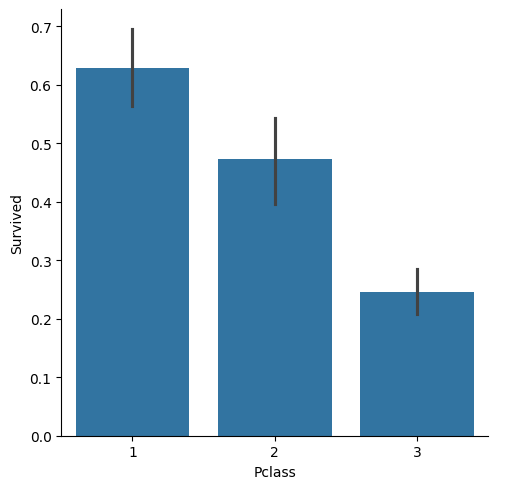

In [168]:
sns.catplot(data=train,x="Pclass",y="Survived",kind="bar")
# More elite passenger classes have higher survival rates

In [169]:
# There are only 2 missing values in embarked in train and none in test : Just replace with most frequent
dataset["Embarked"]=dataset["Embarked"].fillna("S")


**FILLING/IMPUTING MISSING VALUES**

Imputing Age

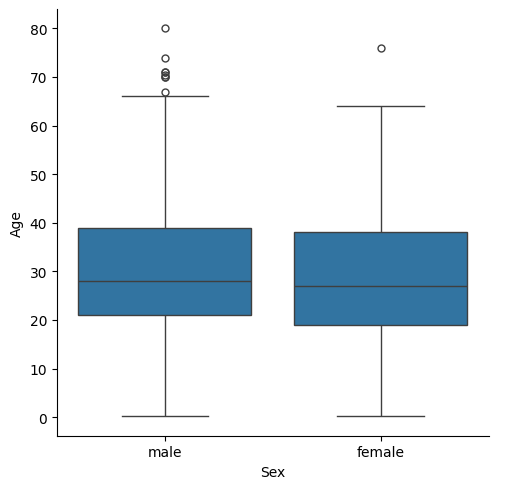

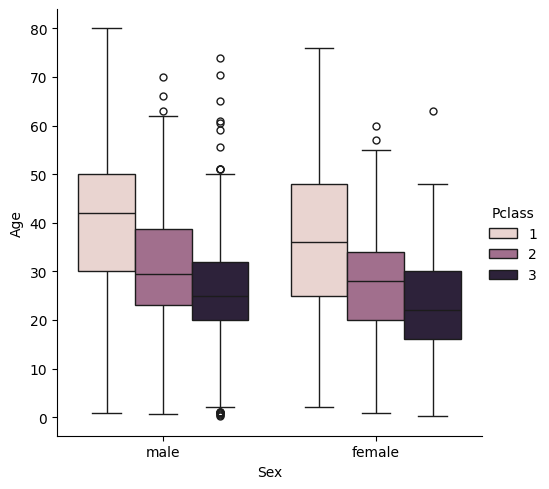

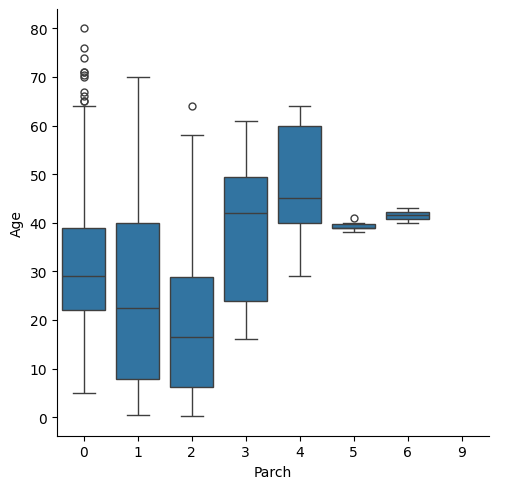

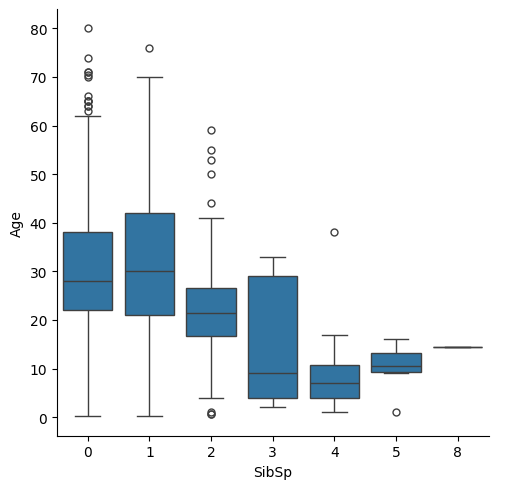

In [170]:
# Age is missing in many examples but has important subset - lower age groups have a high survival chance - So we should impute

g = sns.catplot(data=dataset,y="Age",kind="box",x="Sex")
g = sns.catplot(data=dataset,y="Age",kind="box",x="Sex",hue="Pclass")
g = sns.catplot(y="Age",x="Parch",data=dataset,kind="box")
g = sns.catplot(y="Age",x="SibSp",data=dataset,kind="box")

In [171]:
# Sex and Age are pretty unrelated it seems
# Notice how age follows 1st class > 2nd class > 3rd class order
# Lower Age passengers have higher SibSp
# Higher Age passengers have higher Parch

In [172]:
# Convert Sex to numeric data for checking correlation
dataset["Sex"]=dataset["Sex"].map({"male":0,"female":1})

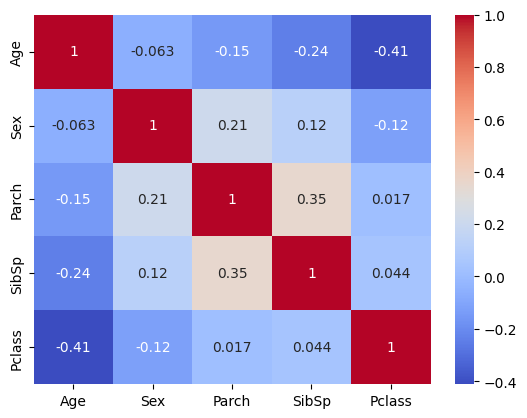

In [173]:
g = sns.heatmap(dataset[["Age","Sex","Parch","SibSp","Pclass"]].corr(),cmap="coolwarm",annot=True)
# Surprisingly there is a (substantial) negative correlation of age with Parch,SibSp,Pclass - so it is useful data for imputing

In [174]:
index_NaN_age = list(dataset["Age"][dataset["Age"].isnull()].index)

for i in index_NaN_age :
    age_med = dataset["Age"].median()
    age_pred = dataset[((dataset['SibSp'] == dataset.iloc[i]["SibSp"]) & (dataset['Parch'] == dataset.iloc[i]["Parch"]) & (dataset['Pclass'] == dataset.iloc[i]["Pclass"]))]["Age"].median()
    if not np.isnan(age_pred) :
        dataset.loc[i,"Age"] = age_pred
    else :
        dataset.loc[i,"Age"] = age_med


**FEATURE ENGINEERING**

Bringing Name to useable  form

In [175]:
dataset["Name"].head()

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: object

In [176]:
# Only the title could be important from the name attribute of data - hence we must extract it separately

dataset_title = [i.split(',')[1].split('.')[0].strip() for i in dataset["Name"]]
dataset["Name"] = dataset_title


In [177]:
dataset["Name"].head()

0      Mr
1     Mrs
2    Miss
3     Mrs
4      Mr
Name: Name, dtype: object

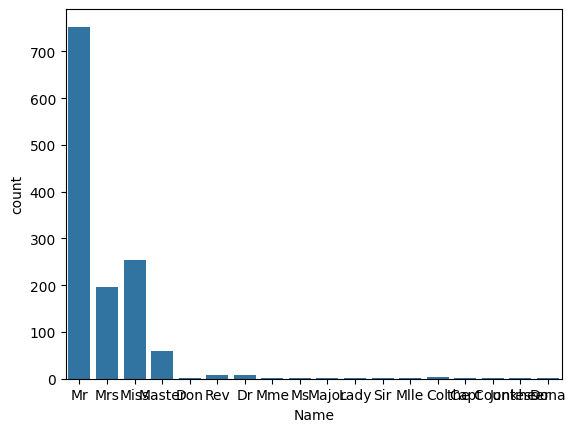

In [178]:
g = sns.countplot(x="Name",data=dataset)
# Most titles are very rare

In [179]:
dataset["Name"] = dataset["Name"].replace(['Lady','the Countess','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],'Rare')
dataset["Name"] = dataset["Name"].map({"Master":0,"Miss":1,"Ms" : 1 ,"Mme":1,"Mlle":1,"Mrs":1,"Mr":2,"Rare":3})
dataset["Name"] = dataset["Name"].astype(int)

Categorising Family Sizes

In [180]:
dataset["Family_Size"]=1+dataset["Parch"]+dataset["SibSp"]

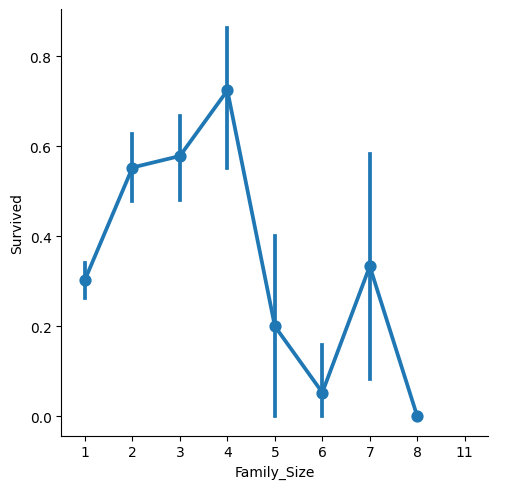

In [181]:
sns.catplot(data=dataset,x="Family_Size",y="Survived",kind="point")
# Survival is very hard for large families

In [182]:
dataset['Single'] = dataset['Family_Size'].map(lambda s: 1 if s == 1 else 0)
dataset['SmallF'] = dataset['Family_Size'].map(lambda s: 1 if  s == 2  else 0)
dataset['MedF'] = dataset['Family_Size'].map(lambda s: 1 if 3 <= s <= 4 else 0)
dataset['LargeF'] = dataset['Family_Size'].map(lambda s: 1 if s >= 5 else 0)

In [183]:
dataset = pd.get_dummies(dataset,columns=["Name"])
dataset = pd.get_dummies(dataset,columns=["Embarked"],prefix="Em")

In [184]:
dataset.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,...,SmallF,MedF,LargeF,Name_0,Name_1,Name_2,Name_3,Em_C,Em_Q,Em_S
0,1,0.0,3,0,22.0,1,0,A/5 21171,1.981001,NaN,...,1,0,0,False,False,True,False,False,False,True
1,2,1.0,1,1,38.0,1,0,PC 17599,4.266662,C85,...,1,0,0,False,True,False,False,True,False,False
2,3,1.0,3,1,26.0,0,0,STON/O2. 3101282,2.070022,NaN,...,0,0,0,False,True,False,False,False,False,True
3,4,1.0,1,1,35.0,1,0,113803,3.972177,C123,...,1,0,0,False,True,False,False,False,False,True
4,5,0.0,3,0,35.0,0,0,373450,2.085672,NaN,...,0,0,0,False,False,True,False,False,False,True


Creating Cabin Dummies

In [185]:
dataset["Cabin"].head()

0     NaN
1     C85
2     NaN
3    C123
4     NaN
Name: Cabin, dtype: object

In [186]:
dataset["Cabin"].isnull().sum()

np.int64(1007)

In [187]:
dataset["Cabin"].describe()

count     292
unique    186
top        G6
freq        5
Name: Cabin, dtype: object

In [188]:
# We only care about the class of the cabin and not the number and lets put NaN as Cabin X
dataset["Cabin"] = [i[0] if not pd.isnull(i) else 'X' for i in dataset["Cabin"]]

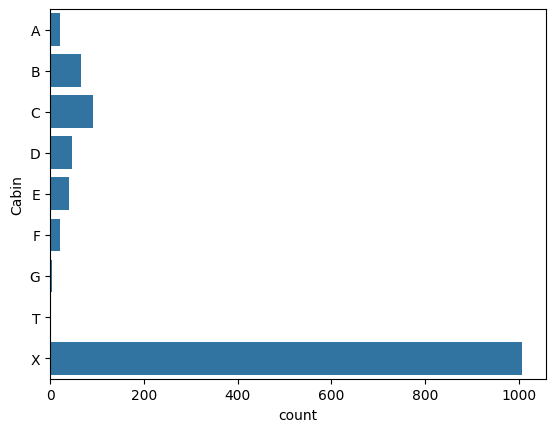

In [189]:
g = sns.countplot(dataset["Cabin"],order=['A','B','C','D','E','F','G','T','X'])

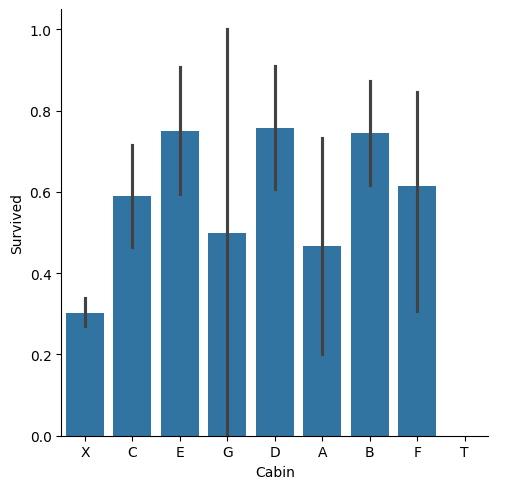

In [190]:
g = sns.catplot(data=dataset,x="Cabin",y="Survived",kind="bar")
# Cabin passenger have a higher chance of survival

In [191]:
dataset = pd.get_dummies(dataset,columns=["Cabin"],prefix="Cabin")

Categorising Ticket by Ticket Prefix

In [192]:
dataset["Ticket"].head()

0           A/5 21171
1            PC 17599
2    STON/O2. 3101282
3              113803
4              373450
Name: Ticket, dtype: object

In [193]:
Ticket = []
for i in list(dataset.Ticket):
    if not i.isdigit() :
        Ticket.append(i.replace(".","").replace("/","").strip().split(' ')[0])
    else:
        Ticket.append("X")
        
dataset["Ticket"] = Ticket
dataset["Ticket"].head()

0        A5
1        PC
2    STONO2
3         X
4         X
Name: Ticket, dtype: object

In [194]:
dataset = pd.get_dummies(dataset,columns=["Ticket"],prefix="Tkt")

Categorising Pclass

In [195]:
dataset["Pclass"] = dataset["Pclass"].astype("category")
dataset = pd.get_dummies(dataset, columns = ["Pclass"],prefix="Pc")

In [196]:
# Drop the remaining useless variables
dataset.drop(labels=["PassengerId"],axis=1,inplace=True)

In [197]:
dataset.head()

,Survived,Sex,Age,SibSp,Parch,Fare,Family_Size,Single,SmallF,MedF,...,Tkt_STONO,Tkt_STONO2,Tkt_STONOQ,Tkt_SWPP,Tkt_WC,Tkt_WEP,Tkt_X,Pc_1,Pc_2,Pc_3
0,0.0,0,22.0,1,0,1.981001,2,0,1,0,...,False,False,False,False,False,False,False,False,False,True
1,1.0,1,38.0,1,0,4.266662,2,0,1,0,...,False,False,False,False,False,False,False,True,False,False
2,1.0,1,26.0,0,0,2.070022,1,1,0,0,...,False,True,False,False,False,False,False,False,False,True
3,1.0,1,35.0,1,0,3.972177,2,0,1,0,...,False,False,False,False,False,False,True,True,False,False
4,0.0,0,35.0,0,0,2.085672,1,1,0,0,...,False,False,False,False,False,False,True,False,False,True


In [198]:
dataset = dataset.replace({True: 1, False: 0, "True": 1, "False": 0})

/tmp/ipykernel_58/1843018159.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset = dataset.replace({True: 1, False: 0, "True": 1, "False": 0})


In [199]:
dataset.head()

,Survived,Sex,Age,SibSp,Parch,Fare,Family_Size,Single,SmallF,MedF,...,Tkt_STONO,Tkt_STONO2,Tkt_STONOQ,Tkt_SWPP,Tkt_WC,Tkt_WEP,Tkt_X,Pc_1,Pc_2,Pc_3
0,0.0,0,22.0,1,0,1.981001,2,0,1,0,...,0,0,0,0,0,0,0,0,0,1
1,1.0,1,38.0,1,0,4.266662,2,0,1,0,...,0,0,0,0,0,0,0,1,0,0
2,1.0,1,26.0,0,0,2.070022,1,1,0,0,...,0,1,0,0,0,0,0,0,0,1
3,1.0,1,35.0,1,0,3.972177,2,0,1,0,...,0,0,0,0,0,0,1,1,0,0
4,0.0,0,35.0,0,0,2.085672,1,1,0,0,...,0,0,0,0,0,0,1,0,0,1


**MODEL**

In [200]:
test = dataset[-418:]
train = dataset[:-418]

In [201]:
test.drop(labels=["Survived"],axis=1,inplace=True)

/tmp/ipykernel_58/3782384429.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.drop(labels=["Survived"],axis=1,inplace=True)


In [202]:
y_train = train["Survived"].astype(int)
X_train = train.drop(labels=["Survived"],axis=1)

In [203]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier,ExtraTreesClassifier,VotingClassifier
from sklearn.model_selection import GridSearchCV,cross_val_score,StratifiedKFold,learning_curve

In [204]:
kfold = StratifiedKFold(n_splits=10)

Ensemble model of SVC DecisionTreeClassifier AdaBoostClassifier ExtraTreesClassifier GradientBoostingClassifier

In [205]:
DTC = DecisionTreeClassifier()
AdaDTC = AdaBoostClassifier(DTC,random_state=42)
ada_param_grid = {"estimator__criterion" : ["gini", "entropy"],
              "estimator__splitter" :   ["best", "random"],
              "n_estimators" :[1,2],
              "learning_rate":  [0.0001, 0.001, 0.01, 0.1, 0.2, 0.3,1.5]}

GsAdaDTC = GridSearchCV(AdaDTC,param_grid=ada_param_grid,cv=kfold,scoring="accuracy",n_jobs=-1,verbose = 3)
GsAdaDTC.fit(X_train,y_train)
ada_best = GsAdaDTC.best_estimator_
print("Best Score:", GsAdaDTC.best_score_)
print("Best Params:", GsAdaDTC.best_params_)

Fitting 10 folds for each of 56 candidates, totalling 560 fits
[CV 1/10] END estimator__criterion=gini, estimator__splitter=best, learning_rate=0.0001, n_estimators=1;, score=0.719 total time=   0.0s
[CV 5/10] END estimator__criterion=gini, estimator__splitter=best, learning_rate=0.0001, n_estimators=1;, score=0.830 total time=   0.0s
[CV 6/10] END estimator__criterion=gini, estimator__splitter=best, learning_rate=0.0001, n_estimators=1;, score=0.830 total time=   0.0s
[CV 7/10] END estimator__criterion=gini, estimator__splitter=best, learning_rate=0.0001, n_estimators=1;, score=0.807 total time=   0.0s
[CV 10/10] END estimator__criterion=gini, estimator__splitter=best, learning_rate=0.0001, n_estimators=1;, score=0.841 total time=   0.0s
[CV 3/10] END estimator__criterion=gini, estimator__splitter=best, learning_rate=0.0001, n_estimators=2;, score=0.705 total time=   0.0s
[CV 7/10] END estimator__criterion=gini, estimator__splitter=best, learning_rate=0.0001, n_estimators=2;, score=0.

In [206]:
ExtC = ExtraTreesClassifier()

ex_param_grid = {"max_depth": [None],
              "max_features": [1, 3, 10],
              "min_samples_split": [2, 3, 10],
              "min_samples_leaf": [1, 3, 10],
              "bootstrap": [False],
              "n_estimators" :[100,300],
              "criterion": ["gini"]}

GsExtC = GridSearchCV(ExtC,param_grid=ex_param_grid,cv=kfold,scoring="accuracy",n_jobs=-1,verbose=3)
GsExtC.fit(X_train,y_train)
ExtC_best = GsExtC.best_estimator_

print("Best Score:",GsExtC.best_score_)
print("Best Params:",GsExtC.best_params_)

Fitting 10 folds for each of 54 candidates, totalling 540 fits

[CV 5/10] END estimator__criterion=entropy, estimator__splitter=random, learning_rate=0.01, n_estimators=1;, score=0.852 total time=   0.0s
[CV 6/10] END estimator__criterion=entropy, estimator__splitter=random, learning_rate=0.01, n_estimators=1;, score=0.818 total time=   0.0s
[CV 7/10] END estimator__criterion=entropy, estimator__splitter=random, learning_rate=0.01, n_estimators=1;, score=0.830 total time=   0.0s
[CV 8/10] END estimator__criterion=entropy, estimator__splitter=random, learning_rate=0.01, n_estimators=1;, score=0.750 total time=   0.0s
[CV 3/10] END estimator__criterion=entropy, estimator__splitter=random, learning_rate=0.1, n_estimators=2;, score=0.705 total time=   0.0s
[CV 4/10] END estimator__criterion=entropy, estimator__splitter=random, learning_rate=0.1, n_estimators=2;, score=0.830 total time=   0.0s
[CV 5/10] END estimator__criterion=entropy, estimator__splitter=random, learning_rate=0.1, n_estim

In [207]:
RFC = RandomForestClassifier()

rf_param_grid = {"max_depth": [None],
              "max_features": [1, 3, 10],
              "min_samples_split": [2, 3, 10],
              "min_samples_leaf": [1, 3, 10],
              "bootstrap": [False],
              "n_estimators" :[100,300],
              "criterion": ["gini"]}

gsRFC = GridSearchCV(RFC,param_grid = rf_param_grid, cv=kfold, scoring="accuracy", n_jobs= -1, verbose = 3)
gsRFC.fit(X_train,y_train)

RFC_best = gsRFC.best_estimator_

print("Best Score:",gsRFC.best_score_)
print("Best Params:",gsRFC.best_params_)

Fitting 10 folds for each of 54 candidates, totalling 540 fits

[CV 9/10] END bootstrap=False, criterion=gini, max_depth=None, max_features=3, min_samples_leaf=10, min_samples_split=10, n_estimators=300;, score=0.807 total time=   0.6s
[CV 5/10] END bootstrap=False, criterion=gini, max_depth=None, max_features=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.841 total time=   0.3s
[CV 9/10] END bootstrap=False, criterion=gini, max_depth=None, max_features=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.818 total time=   0.3s
[CV 3/10] END bootstrap=False, criterion=gini, max_depth=None, max_features=10, min_samples_leaf=1, min_samples_split=2, n_estimators=300;, score=0.739 total time=   0.9s
[CV 7/10] END bootstrap=False, criterion=gini, max_depth=None, max_features=10, min_samples_leaf=1, min_samples_split=2, n_estimators=300;, score=0.852 total time=   1.0s
[CV 1/10] END bootstrap=False, criterion=gini, max_depth=None, max_features=10, 

In [208]:
GBC = GradientBoostingClassifier(random_state=42)

gbc_param_grid = {
              'n_estimators' : [100,200,300],
              'learning_rate': [0.1, 0.05, 0.01],
              'max_depth': [4, 8],
              'min_samples_leaf': [100,150],
              'max_features': [0.3, 0.1] 
              }

GsGBC = GridSearchCV(GBC,gbc_param_grid,cv=kfold,scoring="accuracy",n_jobs=-1,verbose=3)
GsGBC.fit(X_train,y_train)

GBC_best = GsGBC.best_estimator_

print("Best Score:",GsGBC.best_score_)
print("Best Params:",GsGBC.best_params_)

Fitting 10 folds for each of 72 candidates, totalling 720 fits

[CV 7/10] END bootstrap=False, criterion=gini, max_depth=None, max_features=3, min_samples_leaf=10, min_samples_split=10, n_estimators=300;, score=0.818 total time=   0.6s
[CV 1/10] END bootstrap=False, criterion=gini, max_depth=None, max_features=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.798 total time=   0.4s
[CV 3/10] END bootstrap=False, criterion=gini, max_depth=None, max_features=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.727 total time=   0.4s
[CV 7/10] END bootstrap=False, criterion=gini, max_depth=None, max_features=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.830 total time=   0.4s
[CV 1/10] END bootstrap=False, criterion=gini, max_depth=None, max_features=10, min_samples_leaf=1, min_samples_split=2, n_estimators=300;, score=0.775 total time=   1.0s
[CV 5/10] END bootstrap=False, criterion=gini, max_depth=None, max_features=10, 

In [209]:
SVMC = SVC(probability=True)
svc_param_grid = {'kernel': ['rbf'], 
                  'gamma': [ 0.001,0.01,0.1,1],
                  'C': [1,10,50,100,200,300,1000]}

GsSVMC = GridSearchCV(SVMC,param_grid=svc_param_grid, cv=kfold, scoring="accuracy",n_jobs=-1, verbose = 3)

GsSVMC.fit(X_train,y_train)

SVMC_best = GsSVMC.best_estimator_

# Best score
print("Best Score:",GsSVMC.best_score_)
print("Best Params:",GsSVMC.best_params_)


Fitting 10 folds for each of 28 candidates, totalling 280 fits

[CV 2/10] END learning_rate=0.01, max_depth=4, max_features=0.3, min_samples_leaf=150, n_estimators=300;, score=0.807 total time=   0.5s
[CV 6/10] END learning_rate=0.01, max_depth=4, max_features=0.3, min_samples_leaf=150, n_estimators=300;, score=0.784 total time=   0.5s
[CV 10/10] END learning_rate=0.01, max_depth=4, max_features=0.3, min_samples_leaf=150, n_estimators=300;, score=0.784 total time=   0.5s
[CV 6/10] END learning_rate=0.01, max_depth=4, max_features=0.1, min_samples_leaf=100, n_estimators=100;, score=0.773 total time=   0.2s
[CV 10/10] END learning_rate=0.01, max_depth=4, max_features=0.1, min_samples_leaf=100, n_estimators=100;, score=0.795 total time=   0.2s
[CV 4/10] END learning_rate=0.01, max_depth=4, max_features=0.1, min_samples_leaf=100, n_estimators=200;, score=0.875 total time=   0.3s
[CV 8/10] END learning_rate=0.01, max_depth=4, max_features=0.1, min_samples_leaf=100, n_estimators=200;, score=

In [210]:
VotingClf = VotingClassifier(estimators=[('rfc',RFC_best), ('extc',ExtC_best),
('svc',SVMC_best), ('adac',ada_best),('gbc',GBC_best)],voting='soft',n_jobs=-1)

model = VotingClf.fit(X_train,y_train)

In [212]:
test_Survived = pd.Series(model.predict(test),name="Survived")
results = pd.concat([IDtest,test_Survived],axis=1)

results.to_csv("submission.csv",index=False)


[CV 10/10] END learning_rate=0.01, max_depth=8, max_features=0.1, min_samples_leaf=100, n_estimators=200;, score=0.807 total time=   0.3s
[CV 4/10] END learning_rate=0.01, max_depth=8, max_features=0.1, min_samples_leaf=100, n_estimators=300;, score=0.864 total time=   0.5s
[CV 8/10] END learning_rate=0.01, max_depth=8, max_features=0.1, min_samples_leaf=100, n_estimators=300;, score=0.761 total time=   0.5s
[CV 2/10] END learning_rate=0.01, max_depth=8, max_features=0.1, min_samples_leaf=150, n_estimators=100;, score=0.705 total time=   0.2s
[CV 4/10] END learning_rate=0.01, max_depth=8, max_features=0.1, min_samples_leaf=150, n_estimators=100;, score=0.795 total time=   0.2s
[CV 8/10] END learning_rate=0.01, max_depth=8, max_features=0.1, min_samples_leaf=150, n_estimators=100;, score=0.727 total time=   0.2s
[CV 2/10] END learning_rate=0.01, max_depth=8, max_features=0.1, min_samples_leaf=150, n_estimators=200;, score=0.727 total time=   0.3s
[CV 6/10] END learning_rate=0.01, max_d